# Training

Agregamos la carpeta padre al Path para poder importar el módulo `cowaver`:

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

## Funciones de graficado

In [2]:
import io
import torch
import torchaudio
import ipywidgets as widgets
import cowaver
from cowaver.utils import AUDIO_SAMPLE_RATE

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

In [3]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

DEVICE = encontrar_dispositivo()
DATASET_SIZE = 480

# Idioma, puede ser "french" o "spanish"
LANGUAGE = "spanish"

cross_language_results = {}
cross_language_results[LANGUAGE] = {}

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

print(f"Buscando {compressed_phones_path}", end="... ")
print("OK" if compressed_phones_path.exists() else "ERROR")

print(f"Buscando {compressed_spoken_path}", end="... ")
print("OK" if compressed_spoken_path.exists() else "ERROR")

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando dispositivo... CPU
Buscando ..\spanish\kalulu-phones-480.tar.xz... OK
Buscando ..\spanish\kalulu-spoken-480.tar.xz... OK


In [4]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Total de palabras:", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

Descomprimiendo ..\spanish\kalulu-phones-480.tar.xz en ..\spanish\data\kalulu-phones-480... YA EXISTE
Descomprimiendo ..\spanish\kalulu-spoken-480.tar.xz en ..\spanish\data\kalulu-spoken-480... YA EXISTE
Total de palabras: 480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abierto', 'adulto', 'aire', 'alta', 'alumno', 'ama', 'ancho', 'artista', 'atleta', 'azúcar', 'bandera', 'calle', 'calor', 'cero', 'cerro', 'cohete', 'con', 'copa', 'cruzar', 'culpa', 'dado', 'dama', 'dejar', 'doce', 'enseña', 'era', 'esquina', 'fama', 'faro', 'feliz', 'fino', 'fruta', 'gracias', 'grande', 'helado', 'himno', 'idea', 'jugar', 'lava', 'lengua', 'limpio', 'los', 'luchar', 'magia', 'mancha', 'manga', 'marzo', 'medida', 'mes', 'miedo', 'modelo', 'moneda', 'montaña', 'mágico', 'música', 'niños', 'novios', 'nube', 'nudo', 'nueve', 'nuevo', 'octubre', 'oficina', 'ojo', 'parque', 'paseo', 'persona', 'pie', 'piel', 'pino', 'pintor', 'pintura', 'plana', 'planta', 'pluma', 'ratones', 'raíz', 'reino', 'ro

In [5]:
import matplotlib.pyplot as plt
from cowaver.datamodules import TinyPairedMel
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
test_set = paired_data.test_set

@widgets.interact(idx=(0, len(test_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = test_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4), layout="constrained")
        fig.suptitle(test_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        plt.show()

    display(widgets.VBox([out, widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform)])]))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

In [6]:
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

import cowaver
from cowaver.modules.autoencoders import ConvAutoEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableMixin
from cowaver.utils import distancia_mel, topk
    
class TrainableConvAutoEncoder(TrainableMixin, ConvAutoEncoder):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        self.seq_len = seq_len
        self.mel_bins = mel_bins

    @property
    def name(self) -> str:
        return f"autoencoder_sl{self.seq_len}_mb{self.mel_bins}"

    def training_step(self, batch, batch_idx, phase: int):
        (image, phonetized_mel, spoken_mel), target = batch
        B = image.size(0)
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(spoken_mel)
        return nn.functional.mse_loss(y_hat.reshape(B, -1), target=spoken_mel.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (image, phonetized_mel, spoken_mel), target = batch
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(spoken_mel)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        prototypes = data.mel_prototypes(y_hat.device)
        distances = distancia_mel(y_hat, prototypes)
        return topk(distances, target)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        return LinearLR(optimizer, start_factor=1.0, end_factor=programme.end_factor, total_iters=programme.decay_epochs())

In [7]:
from cowaver.models import TrainProgramme
from cowaver.utils import entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# net = TrainableAutoencoder()
# paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
# train_history = entrenar_red(net=net, data=spoken_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(net, train_history=train_history, programme=programme, folder=checkpoints_path / "spoken")

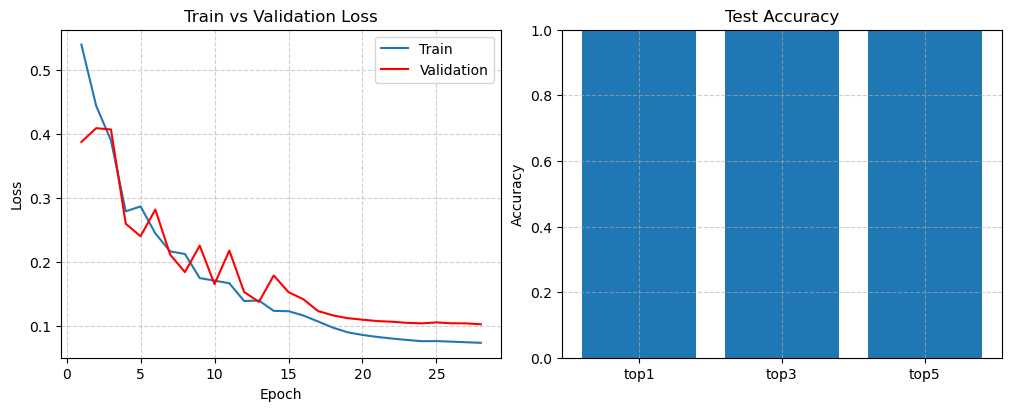

In [8]:
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
net = TrainableConvAutoEncoder()
train_history = cargar_checkpoint(net, folder=checkpoints_path / "spoken", silent=True)
train_history.train_losses = train_history.train_losses[1:]
train_history.val_losses = train_history.val_losses[1:]
test_results = evaluar_red(net, paired_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(test_results, ax=axes[1])
plt.show()

## Red de conciencia fonológica

In [9]:
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

import cowaver
from cowaver.modules.autoencoders import ConvAutoEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableMixin
from cowaver.utils import distancia_mel, topk
    
class PhonologicalAwarenessAutoEncoder(TrainableMixin, ConvAutoEncoder):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        self.seq_len = seq_len
        self.mel_bins = mel_bins

        # Freeze decoder
        for name, param in self.named_parameters():
            if name.startswith("dec_"):
                param.requires_grad = False

    @property
    def name(self) -> str:
        return f"autoencoder_sl{self.seq_len}_mb{self.mel_bins}"

    def training_step(self, batch, batch_idx, phase: int):
        (image, phonetized_mel, spoken_mel), target = batch
        B = image.size(0)
        phonetized_mel = phonetized_mel.transpose(2, 3)
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(phonetized_mel)
        return nn.functional.mse_loss(y_hat.reshape(B, -1), target=spoken_mel.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (image, phonetized_mel, spoken_mel), target = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(phonetized_mel)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        prototypes = data.mel_prototypes(y_hat.device)
        distances = distancia_mel(y_hat, prototypes)
        return topk(distances, target)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        return LinearLR(optimizer, start_factor=1.0, end_factor=programme.end_factor, total_iters=programme.decay_epochs())

In [20]:
programme = TrainProgramme(
    theta_max=30,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# net = PhonologicalAwarenessAutoEncoder()
# paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
# train_history = entrenar_red(net=net, data=paired_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(net, train_history=train_history, programme=programme, folder=checkpoints_path / "paired")

Guardando checkpoint en ..\spanish\checkpoints\480\paired\autoencoder_sl49_mb80_1st_phase.pt... OK


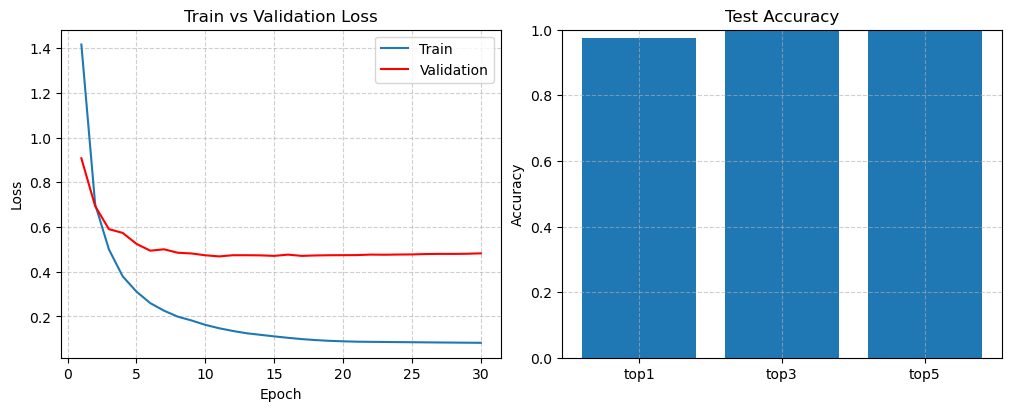

IndexError: index 2 is out of bounds for axis 0 with size 2

In [21]:
from cowaver.utils import evaluar_red
#from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

net = PhonologicalAwarenessAutoEncoder()
train_history = cargar_checkpoint(net, folder=checkpoints_path / "paired", silent=True)

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
training_test_results = evaluar_red(net, paired_data)

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)
generalization_test_results = evaluar_red(net, paired_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

In [42]:
import matplotlib.pyplot as plt
from cowaver.datamodules import TinyPairedMel
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

net = PhonologicalAwarenessAutoEncoder()
cargar_checkpoint(net, folder=checkpoints_path / "paired", silent=True)
paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
test_set = paired_data.test_set

@widgets.interact(idx=(0, len(test_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = test_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    phonetized_mel = phonetized_mel.unsqueeze(1).transpose(2, 3)
    with torch.no_grad():
        h = net.encode(phonetized_mel.to(DEVICE))
        mel_hat = net.decode(h)
    predicted_mel = mel_hat.squeeze(1).transpose(1, 2)
    predicted_waveform = extraer_waveform(predicted_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(3, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(test_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        graficar_embedding(h, ax=axes[2][0], vmin=h.min(), vmax=h.max())
        graficar_mel(predicted_mel, ax=axes[2][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform), audio_widget(predicted_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Ruta fonológica de la lectura

In [ ]:
from cowaver.modules.encoders import AvgPooledITEncoder

class PhonologicalRoute(TrainableMixin, nn.Module):
    def __init__(self, h_dim=256):
        super().__init__()
        self.h_dim = h_dim
        
        self.encoder = AvgPooledITEncoder()
        self.rnn = nn.RNN(
            input_size=512,
            hidden_size=256,
            nonlinearity='tanh',
            batch_first=True,
            bidirectional=False
        )
        self.proj = nn.Linear(256, h_dim)

        self.register_buffer('h_mean', torch.zeros(h_dim))
        self.register_buffer('h_std', torch.ones(h_dim))

    @property
    def name(self) -> str:
        return f"visual_encoder_hd{self.h_dim}"
        
    def forward(self, x: Tensor) -> Tensor:
        # x = [32, 3, 224, 224]
        h = self.encoder(x)
        # h = [32, 7, 512]
        out, h_n = self.rnn(h)
        return self.proj(h_n[0])

    def training_step(self, batch, batch_idx, phase: int):
        (image, phonetized_mel, _), target = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        with torch.no_grad():
            h = net.encode(y)
            h_norm = (h - self.h_mean) / (self.h_std + 1e-6)
            
        h_hat_norm = self(x)
        return F.mse_loss(h_norm, h_hat_norm)

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (x, _, y), targets = batch
        h_hat_norm = self(x)
        h_hat = h_hat_norm * self.h_std + self.h_mean
        mel_hat = net.autoencoder.decode(h_hat)
        mel_hat = mel_hat.squeeze(1).transpose(1, 2)
        
        prototypes = data.mel_prototypes(mel_hat.device)

        distances = distancia_mel(mel_hat, prototypes)

        k = min(5, distances.size(1))
        topk = distances.topk(k, dim=1, largest=False).indices

        targets = targets.view(-1, 1)

        top1 = (topk[:, :1] == targets).any(dim=1).sum().item()
        top3 = (topk[:, :min(3, k)] == targets).any(dim=1).sum().item()
        top5 = (topk[:, :k] == targets).any(dim=1).sum().item()

        return TestResults(top1=top1, top3=top3, top5=top5)

    def inference_step(self, batch: tuple) -> tuple[Tensor, Tensor]:
        x, _, _, task_ids = unpack_batch(batch)
        return self(x, task_ids=task_ids)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        return AdamW(params=self.parameters(), lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        start_epoch = programme.epochs_before_phase(phase)
        for group in optimizer.param_groups:
            group.setdefault("initial_lr", group["lr"])
        return LinearLR(
            optimizer,
            start_factor=1.0,
            end_factor=programme.end_factor,
            total_iters=programme.decay_epochs(),
            last_epoch=start_epoch - 1,
        )

    def set_h_stats(self, h_mean: Tensor, h_std: Tensor):
        """Llamar una vez, antes de entrenar, con las stats reales del dataset."""
        self.h_mean.copy_(h_mean)
        self.h_std.copy_(h_std)

In [18]:
def ruta_al_checkpoint(net: cowaver.models.TrainableModule, phase: int, folder: Path):
    ordinal = lambda n: "%d%s" % (n,"tsnrhtdd"[(n//10%10!=1)*(n%10<4)*n%10::4])
    return folder / f"{net.name}_{ordinal(phase)}_phase.pt"

def cargar_checkpoint(net: cowaver.models.TrainableModule, folder: Path, silent: bool = False):
    device = torch.device("cpu")
    phase = 1

    path = ruta_al_checkpoint(net, phase, folder)
    ckpt = torch.load(path, map_location=device, weights_only=True)
    net = net.to(device)

    # Some checkpoints wrap the state dict.
    state_dict = ckpt.get("model", ckpt)

    state_dict = {
        key.removeprefix("autoencoder."): value
        for key, value in state_dict.items()
    }

    net.load_state_dict(state_dict, strict=False)
    train_history = cowaver.models.TrainHistory(**ckpt["extra"]["history"])
    num_epochs = train_history.num_epochs
    if not silent:
        imprimir_encabezado(net, phase)
    for epoch in range(num_epochs):
        train_loss = train_history.train_losses[epoch]
        val_loss = train_history.val_losses[epoch]
        if not silent:
            print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
    for test_loss in train_history.test_losses:
        if not silent:
            print(f"Phase {phase} | test_loss={test_loss:.4f}")
    return train_history

net = PhonologicalAwarenessAutoEncoder()
train_history = cargar_checkpoint(net, folder=checkpoints_path / "paired", silent=True)